In [17]:
import json
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
from sklearn.decomposition import PCA
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from scipy.special import softmax
from scipy.spatial import distance
from collections import Counter
from scipy.stats import gaussian_kde
from scipy.stats import entropy
import copy

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA

import networkx as nx
from scipy.stats import skew, kurtosis, norm, powerlaw, gaussian_kde, kstest, poisson, norm
from collections import Counter

from sklearn.cluster import KMeans
from scipy.sparse.csgraph import laplacian

import torch
from scipy.stats import kendalltau

In [18]:
countries_list = ['Palau', 'Mozambique', 'Bangladesh', 'French polynesia', 'Botswana', 'Libya', 'Togo', 'Nauru', 
                  'Romania', 'United arab emirates', 'Russia', 'Cameroon', 'Liechtenstein', 'Kenya', 'Curaçao', 
                  'Guam', 'New caledonia', 'Germany', 'North korea', 'North macedonia', 'Luxembourg', 'Hungary', 
                  'Gabon', 'Cape verde', 'Ireland', 'Japan', 'Slovenia', 'China', 'The gambia', 'Switzerland', 
                  'Israel', 'Slovakia', 'Grenada', 'Trinidad and tobago', 'Mauritania', 'England', 
                  'Papua new guinea', 'Venezuela', 'Algeria', 'Dominica', 'Georgia', 'Greenland', 'Netherlands', 
                  'South africa', 'Afghanistan', 'Iceland', 'Laos', 'Paraguay', 'Poland', 'Brunei', 'Syria', 
                  'Benin', 'Mauritius', 'Ukraine', 'Nigeria', 'Estonia', 'Pakistan', 'Bermuda', 'Sierra leone', 
                  'Philippines', 'Saint vincent and the grenadines', 'Kazakhstan', 'Ecuador', 'Ethiopia', 
                  'Bolivia', 'Yemen', 'Nepal', 'Argentina', 'Puerto rico', 'The bahamas', 'Scotland', 'Greece', 
                  'Italy', 'Northern ireland', 'Lesotho', 'Vietnam', 'Spain', 'Armenia', 'Madagascar', 'Zambia', 
                  'Maldives', 'Portugal', 'Bonaire', 'Ghana', 'Tunisia', 'Comoros', 'Dominican republic', 'Iraq', 
                  'Brazil', 'Andorra', 'India', 'United states of america', 'Lebanon', 'Latvia', 'Finland', 
                  'Malta', 'Lithuania', 'Croatia', 'Cuba', 'Egypt', 'Bulgaria', 'Aruba', 'Oman', 'Taiwan', 'Qatar',
                  'Denmark', 'Somalia', 'Fiji', 'Marshall islands', 'Bosnia and herzegovina', 'Indonesia', 
                  'Equatorial guinea', 'Uruguay', 'Ivory coast', 'Morocco', 'Samoa', 'Monaco', 'Jamaica', 
                  'Malaysia', 'Belgium', 'Chile', 'Suriname', 'South korea', 'New zealand', 'Thailand', 'Angola', 
                  'Peru', 'Barbados', 'Montenegro', 'Senegal', 'Tanzania', 'Australia', 'Austria', 'Chad', 
                  'Mexico', 'Turkiye', 'Sweden', 'South sudan', 'France', 'Burkina faso', 'Guyana', 'Liberia', 
                  'Mongolia', 'Myanmar', 'Wales', 'Namibia', 'Mali', 'Seychelles', 'Colombia', 'Vanuatu', 
                  'Sri lanka', 'Cambodia', 'Saint kitts and nevis', 'Rwanda', 'Bahrain', 'Saudi arabia', 
                  'Czech republic', 'Norway', 'Antigua and barbuda', 'Cyprus', 'Moldova', 'Iran', 'Canada', 
                  'Singapore', 'Jordan', 'Democratic republic of the congo', 'Haiti', 'Palestine', 'Azerbaijan', 
                  'Serbia']

question_map = {'convenience_0': "convenience-1", 'convenience_2': 'convenience-2', 'convenience_3': 'convenience-3',
                'familiarity_0': 'familiarity-1', 'familiarity_1': 'familiarity-2', 'familiarity_2': 'familiarity-3',
                'health_1': 'health-1', 'health_2': 'health-2', 'health_4': 'health-3',
                'holidays_0': 'holidays-1', 'holidays_1': 'holidays-2', 'holidays_2': 'holidays-3',
                'house_0': 'house-1', 'house_1': 'house-2', 'house_2': 'house-3',
                'national_0': 'national-1', 'national_1': 'national-2', 'national_2': 'national-3', 
                'languages_0': 'languages-1', 'languages_1': 'languages-2', 'languages_2': 'languages-3',  
                "religions_0": "religions-1", "religions_1": "religions-2", "religions_2": "religions-3",
                "currency_0": "currency-1", "currency_1": "currency-2", "currency_2": "currency-3",}

(84, 20) 9
Counter({'Most common across countries': 61}) Counter({'Somewhat confident': 49, 'Very confident': 26, 'Not confident': 7})


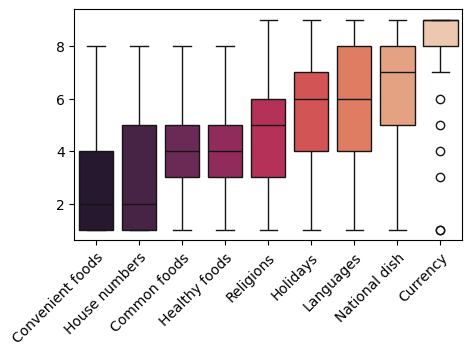

In [19]:
""" LOAD HUAMN DATA """
human_df = pd.read_csv("data/human_rankings.csv")

def format_response(x):
    return int(x.split("(")[0].strip())

def format_attention(x):
    return x.split("–")[0].strip().split("and")[0].strip()

col_names = ['Timestamp', 'Consent', 'ProlificID', 'Country', 'Cultures', 'Convenient foods', 'Common foods', 
             'Healthy foods', 'House numbers', 'National dish', 'Languages', 'Religions', 'Currency', 'Holidays', 
             'AttentionCheck', 'MostDifferent', 'RankingConfidence', 'RateStudy']

questions = ['Convenient foods', 'Common foods', 'Healthy foods', 'House numbers', 'National dish', 
             'Languages', 'Religions', 'Currency', 'Holidays']

human_df.columns = col_names
human_df["Region"] = human_df['Country'].apply(lambda x: x.split("(")[0].strip())
human_df["MostDifferent"] = human_df["MostDifferent"].apply(lambda x: format_attention(x))
for q in questions:
    human_df[q] = human_df[q].apply(lambda x: format_response(x))
    
human_df["is_valid"] = [row[row['MostDifferent']] >= 8 for _, row in human_df.iterrows()]
print(human_df.shape, len(questions))
human_df.head(1)

print(Counter(human_df[(human_df['Region'] != "Other") & (human_df['is_valid'])].AttentionCheck), Counter(human_df[(human_df['Region'] != "Other")].RankingConfidence))

global_mean_rank = human_df[(human_df['Region'] != "Other") & 
                            (human_df['is_valid'])][questions].mean().sort_values()
global_std = human_df[(human_df['Region'] != "Other") & 
                      (human_df['is_valid'])][questions].std()#.sort_values()
global_ranking = global_mean_rank.rank().astype(int)

meandf = pd.DataFrame(global_mean_rank).reset_index()
stddf = pd.DataFrame(global_std).reset_index()
meandf.columns = ["Domain", "mean"]
stddf.columns = ["Domain", "std"]
combodf = meandf.merge(stddf)
combodf["mean_rank"] = combodf["mean"].rank().astype(int)
combodf["std_rank"] = combodf["std"].rank().astype(int)
combodf.sort_values("mean_rank")

plt.figure(figsize=(5,3))
g = sns.boxplot(human_df[(human_df['Region'] != "Other") & 
                         (human_df['is_valid'])][global_mean_rank.keys()], 
                palette=sns.color_palette("rocket", 9, as_cmap=False))
plt.setp(g.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.show()

In [20]:
domain_clusters = {'Convenient foods': "Most Common (HH)", 'House numbers': "Most Common (LH)", 
                   'Common foods': "Common (HH)", 'Healthy foods': "Common (HH)", 
                   'Religions': "Less Common (LL)", 'Holidays': "Less Common (LL)", 'Languages': "Less Common (LL)", 
                   'National dish': "Least Common (HL)", 'Currency': "Least Common (HL)"}

In [22]:
def convert_to_distribution(x):
    log_prob_ = np.asarray(x)
    return softmax(log_prob_, -1)

def cosine_sim_matrix(X):
    """Compute cosine similarity matrix between rows of X."""
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    Xn = X / norms
    return Xn @ Xn.T

def get_eign_decomp(mat, tol=1e-12):
    eigval, eigvec = np.linalg.eig(mat)  
    eigval_sort = np.argsort(-eigval)
    eigval, eigvec = eigval[eigval_sort], eigvec[eigval_sort]    
    eigvals = eigval[eigval > tol]  # drop ~zero eigenvalues
    if eigvals.size == 0:
        erank = 0.0
    else:
        p = np.real(eigvals / eigvals.sum())
        p_nonzero = p[p > 0]
        erank = np.exp(-np.sum(p_nonzero * np.log(p_nonzero)))
    prank = np.real(eigval.sum()**2 / (eigval**2).sum())
    return eigval, np.real(eigval[0]/eigval[1]), erank, prank

In [23]:
path = "outputs/logits_v2"
fnames = {
    "GPT-2": "openai-community_gpt2_logits.pkl",
    "Llama-3.1-8B-it": "meta-llama_Meta-Llama-3.1-8B-Instruct_logits.pkl",
    "Llama-3.2-1B-it": "meta-llama_Llama-3.2-1B-Instruct_logits.pkl",
    "Llama-3.1-70B-it": "meta-llama_Llama-3.1-70B-Instruct_logits.pkl",
    "Gemma-2-9B-it": "google_gemma-2-9b-it_logits.pkl",
    "Gemma-2-2B-it": "google_gemma-2-2b-it_logits.pkl",
    "GPT-J-6B": "EleutherAI_gpt-j-6b_logits.pkl",
    "Aya-8B": "CohereLabs_aya-expanse-8b_logits.pkl"
}

original_dist, top_20_items = {}, {}
option_dict = {}
classification_results = []
eig_dict = {"adjacency_matrix_norm": {}, "eig_list_norm": []}
all_models_eigs_dict = {}

for mname, fname in fnames.items():
    print(f"Running For {mname}")
    data_dict = pickle.load(open(f"{path}/{fname}", "rb"))
    all_models_eigs_dict[mname] = {}
    for q, v in data_dict.items():
        option_dict[q] = list(v.columns)
        v = copy.deepcopy(v.loc[countries_list])
        dist = convert_to_distribution(v)
        if original_dist.get(q, None) is None:
            original_dist[q] = {}
        original_dist[q][mname] = dist
    
        mat_norm = cosine_sim_matrix(dist)
        eig_dict["adjacency_matrix_norm"][q] = copy.deepcopy(mat_norm)
        all_models_eigs_dict[mname][q] = copy.deepcopy(mat_norm)
        
        S_d1_norm, cct_ratio_norm, erank, prank = get_eign_decomp(mat_norm)


        classification_results.append({"question": question_map[q], "model": mname, 
                                       "spectral_ratio": np.round(cct_ratio_norm, 2),
                                       "effective_rank": np.round(erank, 2),
                                      })
        eig_dict["eig_list_norm"].extend([{"question": question_map[q], "model": mname, 
                                           "position": ix, "value": np.round(i, 3)} 
                                          for ix, i in enumerate(np.real(S_d1_norm))])
        
classification_results_df = pd.DataFrame(classification_results)
eig_list_norm_df = pd.DataFrame(eig_dict["eig_list_norm"])
print(classification_results_df.shape, eig_list_norm_df.shape)
classification_results_df.head(2)

Running For GPT-2
Running For Llama-3.1-8B-it
Running For Llama-3.2-1B-it
Running For Llama-3.1-70B-it
Running For Gemma-2-9B-it
Running For Gemma-2-2B-it
Running For GPT-J-6B
Running For Aya-8B
(216, 4) (36720, 4)


,question,model,spectral_ratio,effective_rank
0,convenience-2,GPT-2,10.36,1.93
1,house-2,GPT-2,660.35,1.04


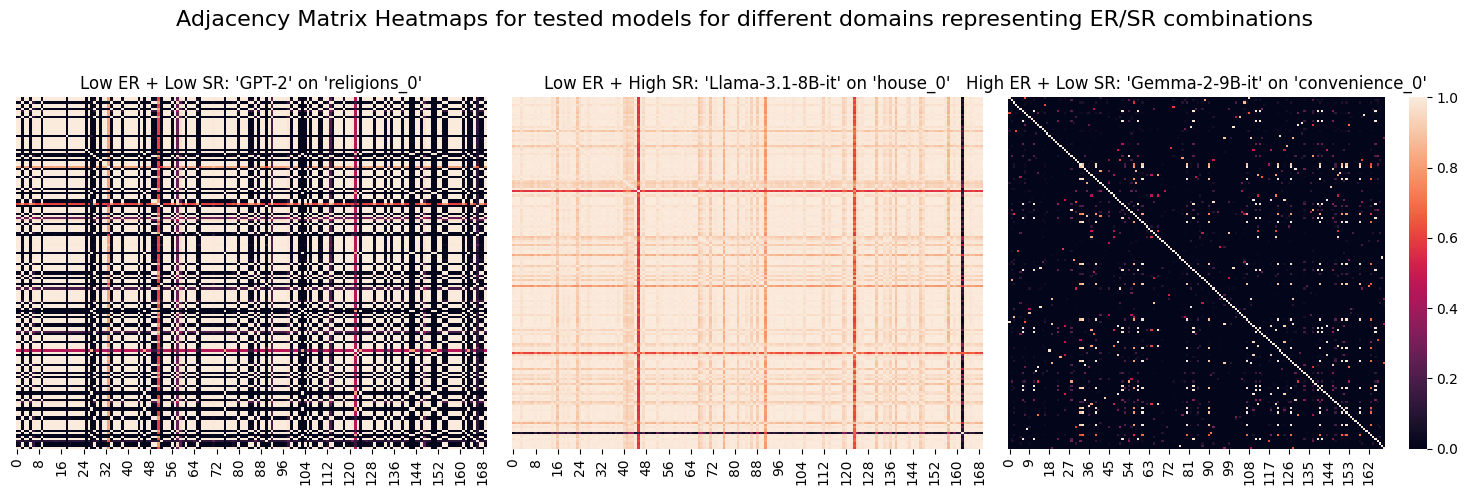

In [81]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle("Adjacency Matrix Heatmaps for tested models for different domains representing ER/SR combinations", fontsize=16)

plot_configs = [
    {'model': 'Aya-8B', 'question': 'religions_0', 'title': "Low ER + Low SR: 'GPT-2' on 'religions_0'"},
    {'model': 'Llama-3.1-8B-it', 'question': 'house_0', 'title': "Low ER + High SR: 'Llama-3.1-8B-it' on 'house_0'"},
    {'model': 'Gemma-2-9B-it', 'question': 'convenience_0', 'title': "High ER + Low SR: 'Gemma-2-9B-it' on 'convenience_0'"}
]

for i, config in enumerate(plot_configs):
    model_name = config['model']
    q_name = config['question']
    title = config['title']
    
    sns.heatmap(all_models_eigs_dict[model_name][q_name], ax=axes[i], cbar=(i == len(plot_configs) - 1))
    axes[i].set_title(title)
    if i >= 0:
        axes[i].set_ylabel('')
        axes[i].set_yticks([])
        # axes[i].set_xticks([])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [79]:
all_models_eigs_dict[model_name][q_name]

array([[1.00000000e+00, 4.62797640e-05, 2.48542352e-05, ...,
        4.40966165e-04, 9.66758802e-05, 8.29346098e-05],
       [4.62797640e-05, 1.00000000e+00, 2.75720086e-03, ...,
        6.55436932e-07, 2.56836462e-06, 1.04728632e-06],
       [2.48542352e-05, 2.75720086e-03, 1.00000000e+00, ...,
        4.90253200e-05, 7.14127269e-04, 1.09592218e-05],
       ...,
       [4.40966165e-04, 6.55436932e-07, 4.90253200e-05, ...,
        1.00000000e+00, 1.75827601e-04, 4.29306127e-05],
       [9.66758802e-05, 2.56836462e-06, 7.14127269e-04, ...,
        1.75827601e-04, 1.00000000e+00, 2.11734446e-05],
       [8.29346098e-05, 1.04728632e-06, 1.09592218e-05, ...,
        4.29306127e-05, 2.11734446e-05, 1.00000000e+00]], shape=(170, 170))

In [83]:
len(all_models_eigs_dict['Aya-8B'])

27

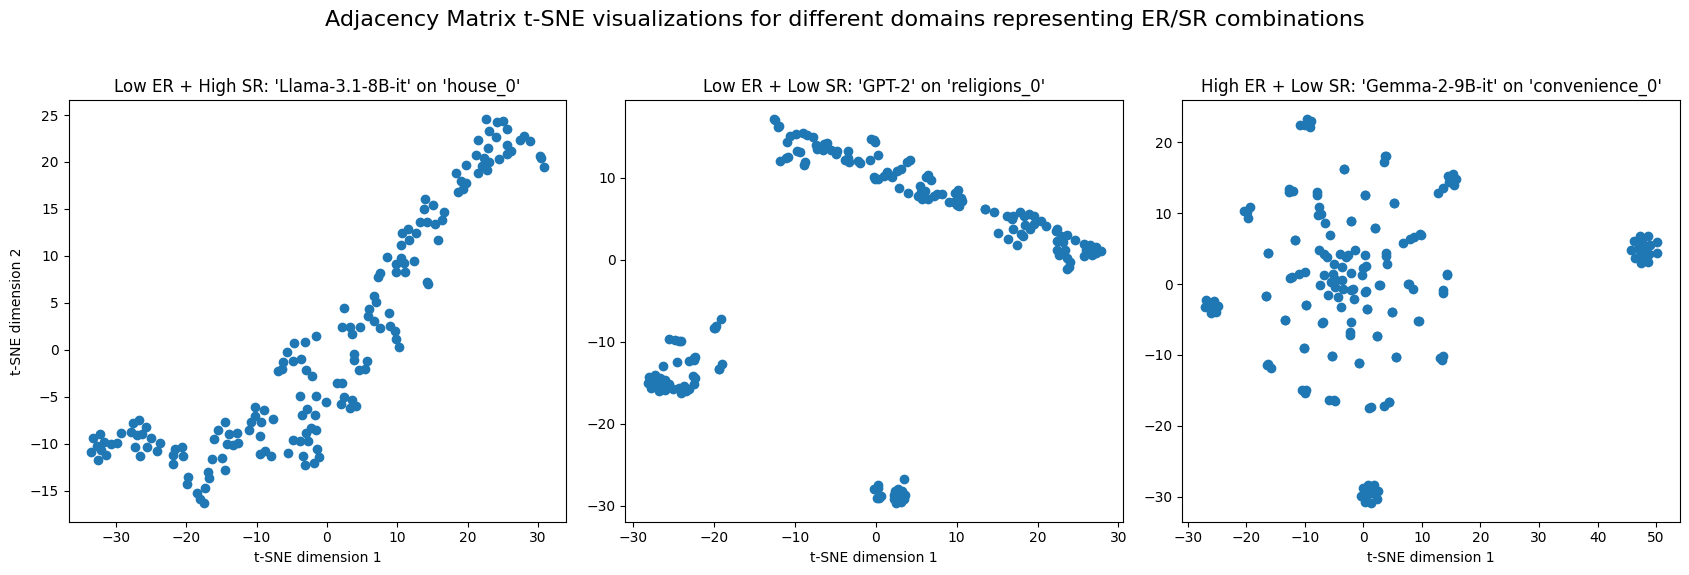

In [80]:
from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle("Adjacency Matrix t-SNE visualizations for different domains representing ER/SR combinations", fontsize=16)
tsne_params = dict(n_components=2, perplexity=15, random_state=42, init="pca")

for i, config in enumerate(plot_configs):
    model_name = config['model']
    q_name = config['question']
    title = config['title']
    
    # The distance matrix is 1 - similarity matrix; ensure non-negative distances and zeros on the diagonal
    # dist_matrix = 1 - all_models_eigs_dict[model_name][q_name]
    # dist_matrix = np.clip(dist_matrix, 0.0, None)
    # np.fill_diagonal(dist_matrix, 0.0)
    
    # Initialize and fit t-SNE (init='random' required for precomputed metric)
    tsne = TSNE(
        **tsne_params
    )
    tsne_results = tsne.fit_transform(all_models_eigs_dict[model_name][q_name])
    
    # Plot the results
    ax = axes[i]
    ax.scatter(tsne_results[:, 0], tsne_results[:, 1])
    ax.set_title(title)
    ax.set_xlabel("t-SNE dimension 1")
    if i == 0:
        ax.set_ylabel("t-SNE dimension 2")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

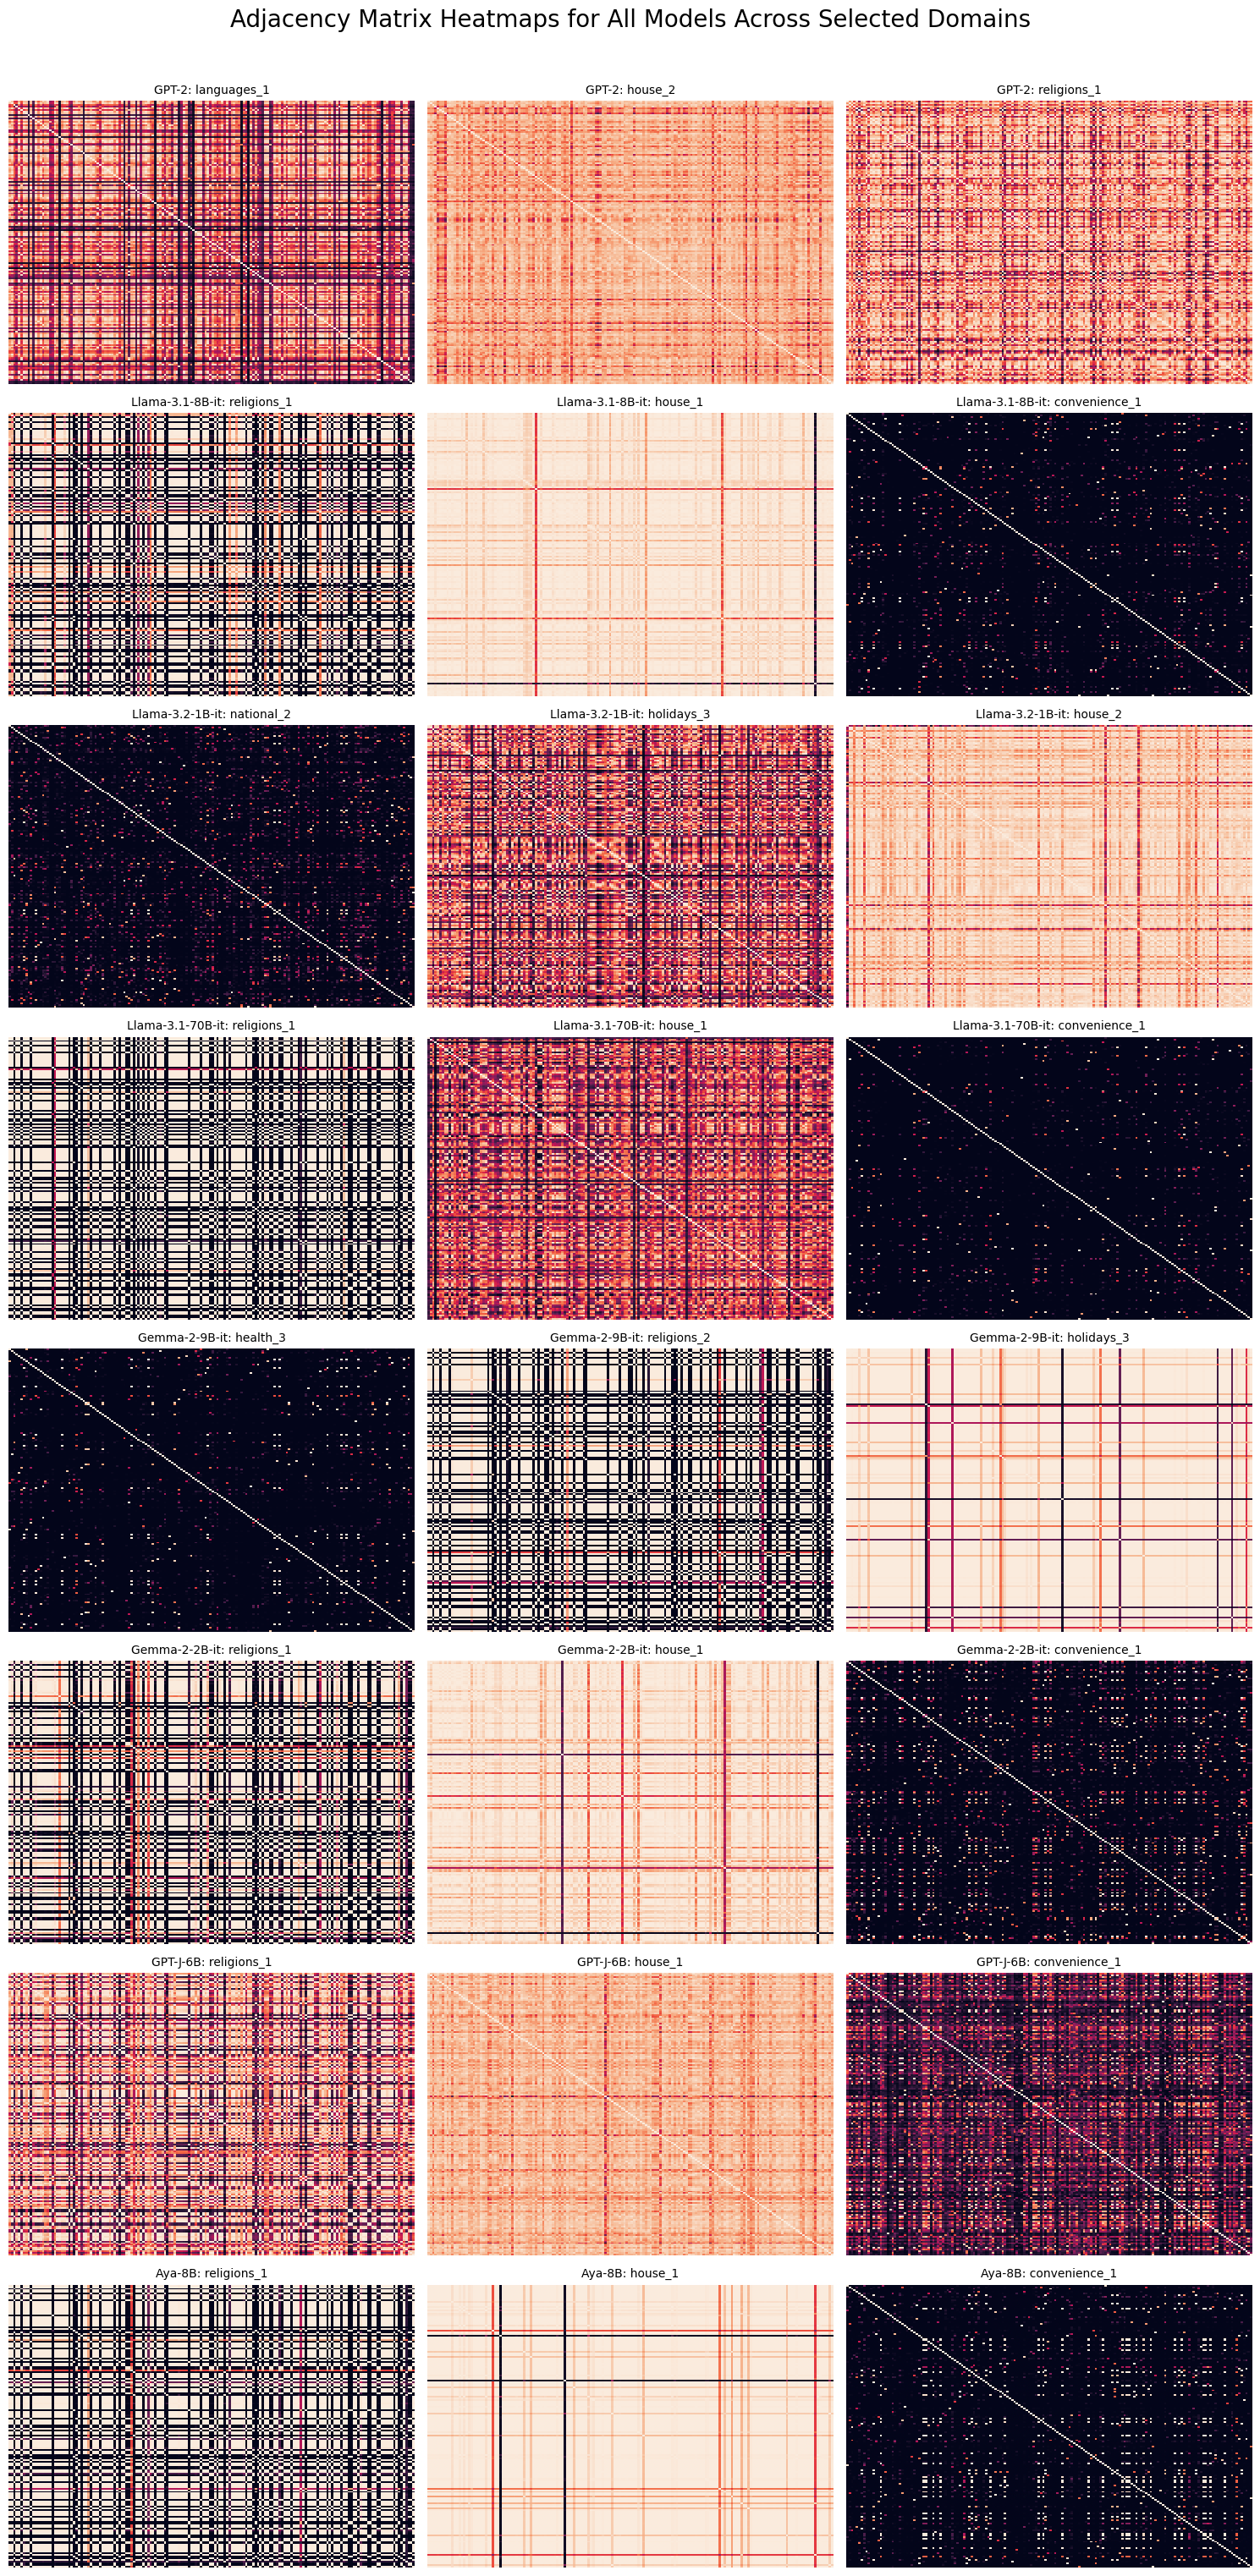

In [87]:
# Define the models and questions to plot for each model
# You can customize the questions and titles for each model here
model_plot_configs = {
    model: {
        'questions': ['religions_0', 'house_0', 'convenience_0'],
        'titles': [
            f"{model.split('_')[0]}: religions_1",
            f"{model.split('_')[0]}: house_1",
            f"{model.split('_')[0]}: convenience_1"
        ]
    } for model in fnames.keys()
}

model_plot_configs['GPT-2']['questions'] = ['languages_0', 'house_1', 'religions_0']
model_plot_configs['GPT-2']['titles'] = ['GPT-2: languages_1', 'GPT-2: house_2', 'GPT-2: religions_1']

model_plot_configs['Gemma-2-9B-it']['questions'] = ['health_2', 'religions_1', "holidays_2"]
model_plot_configs['Gemma-2-9B-it']['titles'] = ['Gemma-2-9B-it: health_3', 'Gemma-2-9B-it: religions_2', 'Gemma-2-9B-it: holidays_3']

model_plot_configs['Llama-3.2-1B-it']['questions'] = ['national_1', 'holidays_2', 'house_1']
model_plot_configs['Llama-3.2-1B-it']['titles'] = ['Llama-3.2-1B-it: national_2', 'Llama-3.2-1B-it: holidays_3', 'Llama-3.2-1B-it: house_2']

# Example of how to set specific questions for a model:
# model_plot_configs['GPT-2']['questions'] = ['languages_0', 'currency_0', 'national_0']
# model_plot_configs['GPT-2']['titles'] = ['GPT-2: languages_0', 'GPT-2: currency_0', 'GPT-2: national_0']


# Create an 8x3 subplot grid
fig, axes = plt.subplots(8, 3, figsize=(15, 32))
fig.suptitle("Adjacency Matrix Heatmaps for All Models Across Selected Domains", fontsize=20)

models_to_plot = list(fnames.keys())

for i, model_name in enumerate(models_to_plot):
    config = model_plot_configs[model_name]
    questions_to_plot = config['questions']
    question_titles = config['titles']
    
    for j, q_name in enumerate(questions_to_plot):
        ax = axes[i, j]
        
        # Plot the heatmap
        sns.heatmap(all_models_eigs_dict[model_name][q_name], ax=ax, cbar=False)
        
        # Set titles for each plot
        ax.set_title(question_titles[j], fontsize=10)
            
        # # Set model names as y-axis labels for the first column
        # if j == 0:
        #     ax.set_ylabel(model_name, fontsize=12, rotation=0, labelpad=50, ha='right')

        # Clean up ticks
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

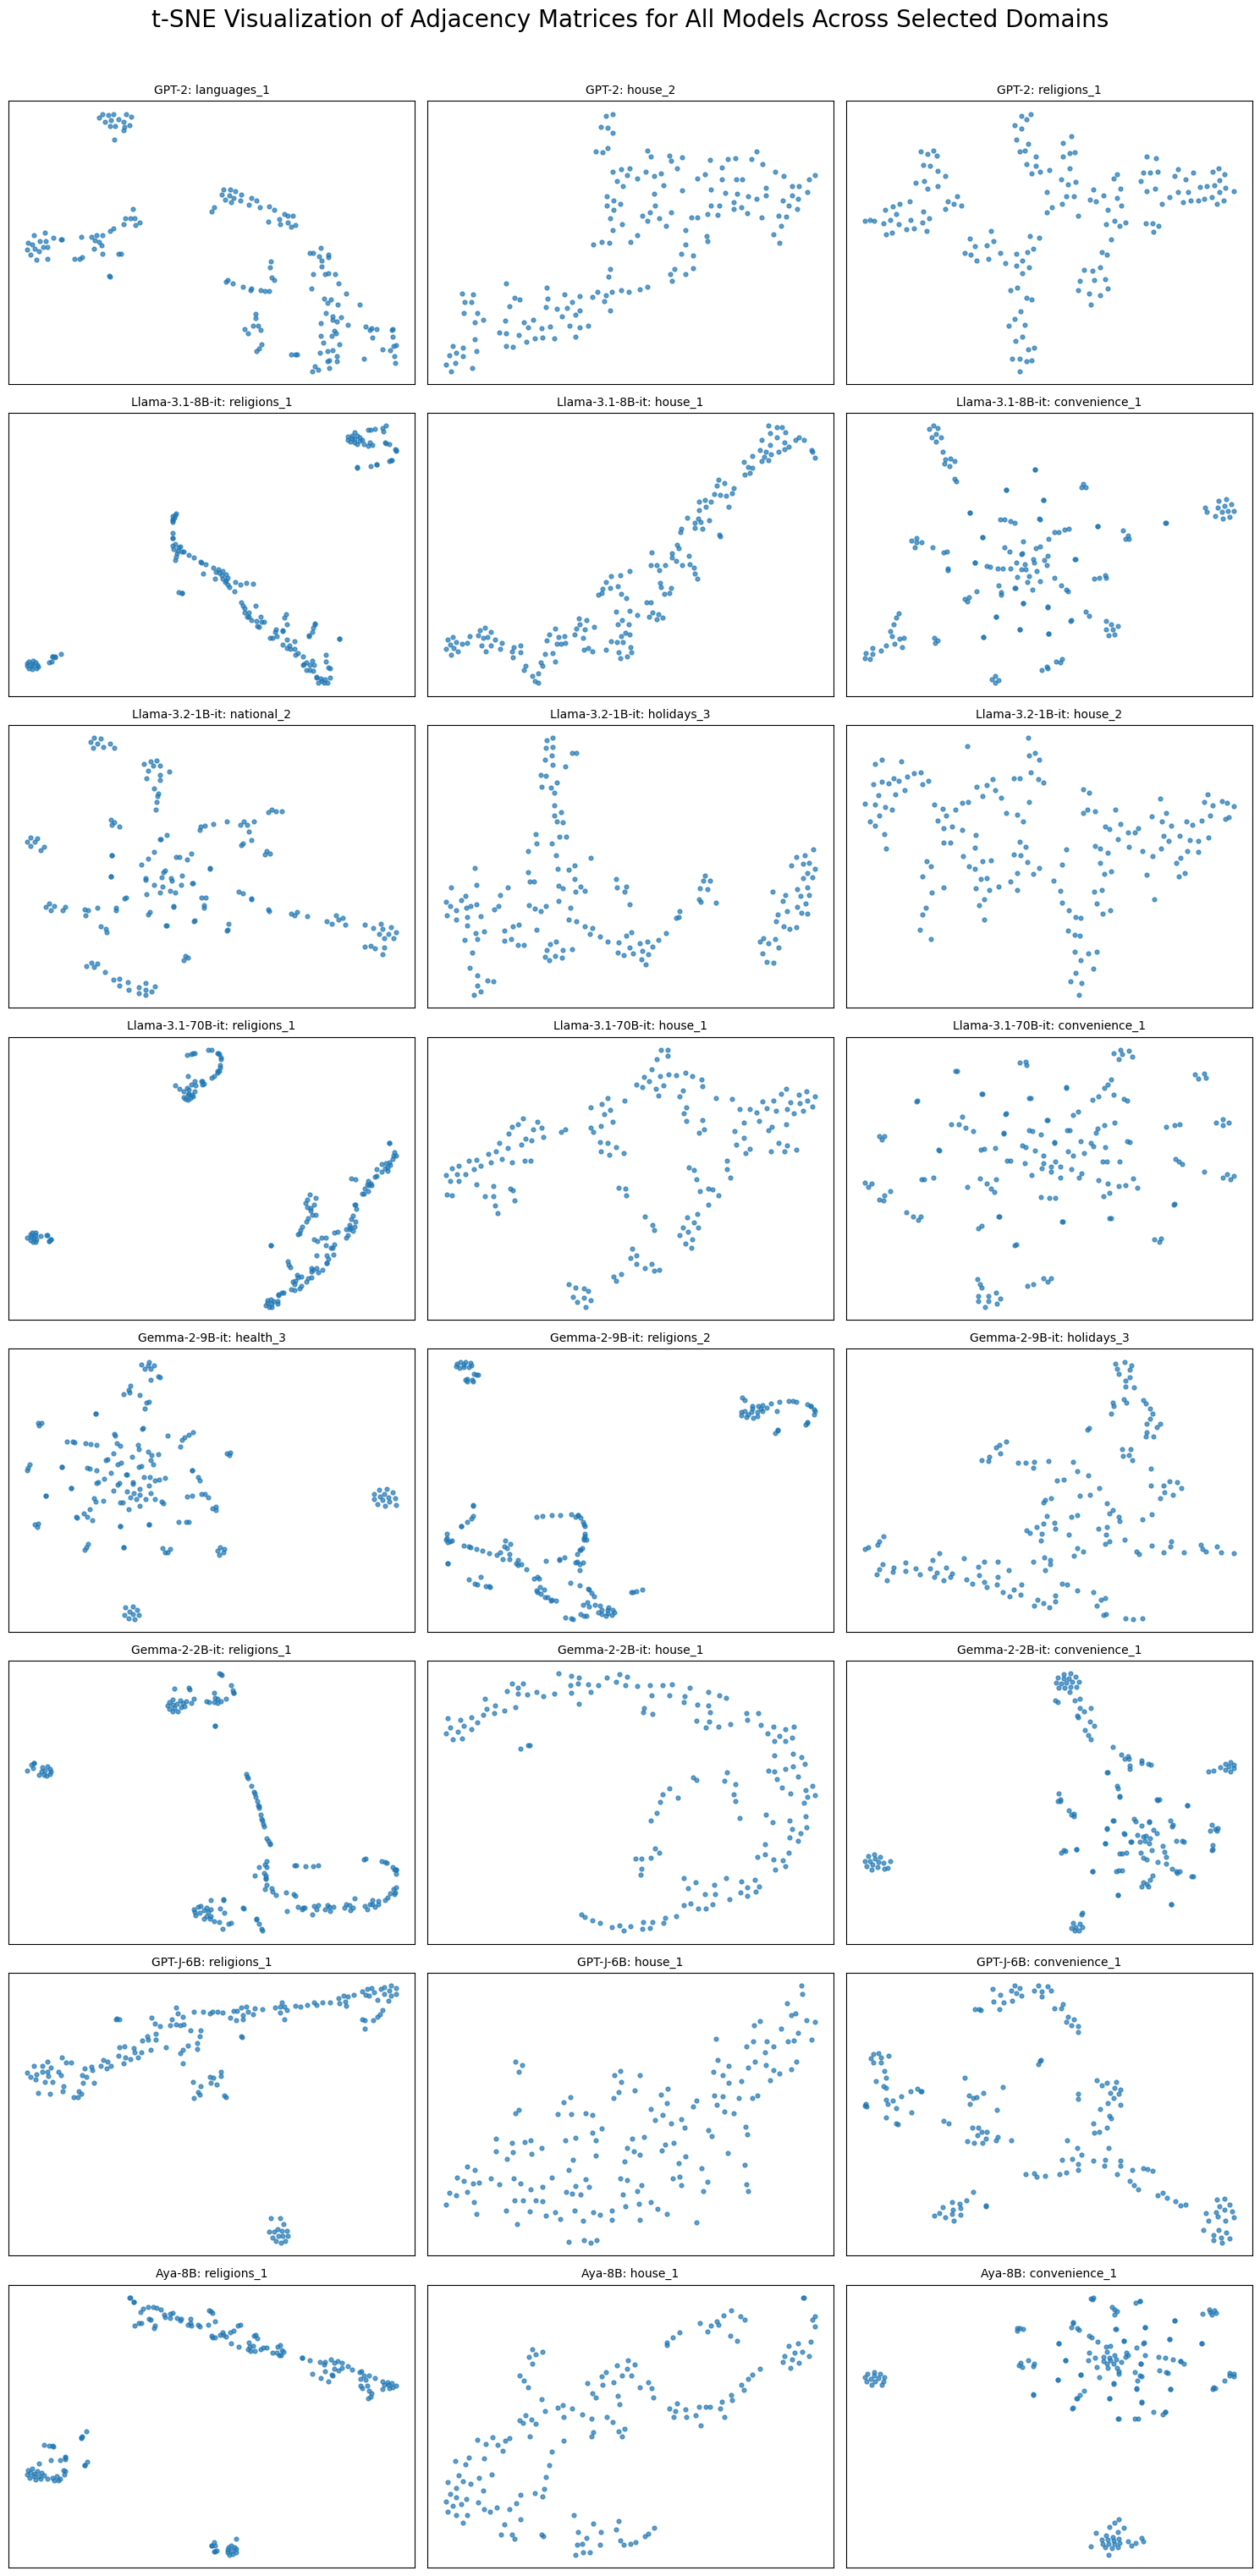

In [90]:
# t-SNE visualizations matching the 8x3 adjacency heatmap grid
tsne_params = dict(n_components=2, perplexity=15, random_state=42, init="pca")
models_to_plot = list(fnames.keys())
fig, axes = plt.subplots(8, 3, figsize=(15, 32))
fig.suptitle("t-SNE Visualization of Adjacency Matrices for All Models Across Selected Domains", fontsize=20)
for i, model_name in enumerate(models_to_plot):
    config = model_plot_configs[model_name]
    questions_to_plot = config['questions']
    question_titles = config['titles']
    for j, q_name in enumerate(questions_to_plot):
        ax = axes[i, j]
        sim_matrix = all_models_eigs_dict[model_name][q_name]
        tsne = TSNE(**tsne_params)
        tsne_results = tsne.fit_transform(sim_matrix)
        ax.scatter(tsne_results[:, 0], tsne_results[:, 1], s=12, alpha=0.7)
        ax.set_title(question_titles[j], fontsize=10)
        # if j == 0:
        #     ax.set_ylabel(model_name, fontsize=9, rotation=0, labelpad=35, ha='right', va='center')
        ax.set_xticks([])
        ax.set_yticks([])
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

In [ ]:
""" CORRELATIONS (Table 4)"""
corrdf = classification_results_df.groupby(["model"])[['spectral_ratio','effective_rank']].corr().reset_index()
corrdf[corrdf["level_1"] == "spectral_ratio"][["model",'effective_rank']].sort_values("effective_rank").reset_index(drop=True)

,model,effective_rank
0,Llama-3.1-70B-it,-0.641789
1,Gemma-2-2B-it,-0.488134
2,GPT-J-6B,-0.479580
3,Llama-3.2-1B-it,-0.452778
4,Gemma-2-9B-it,-0.418509
5,GPT-2,-0.391402
6,Llama-3.1-8B-it,-0.294354
7,Aya-8B,-0.277544


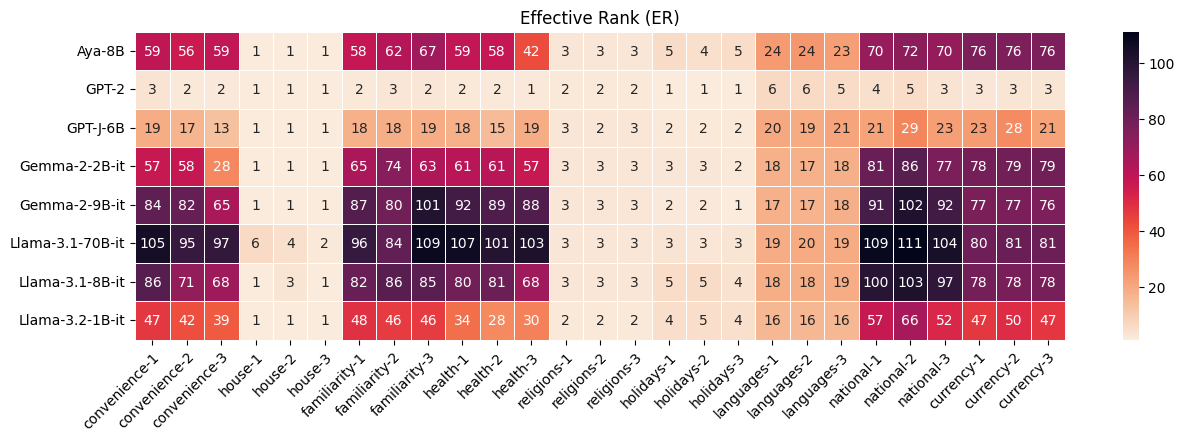

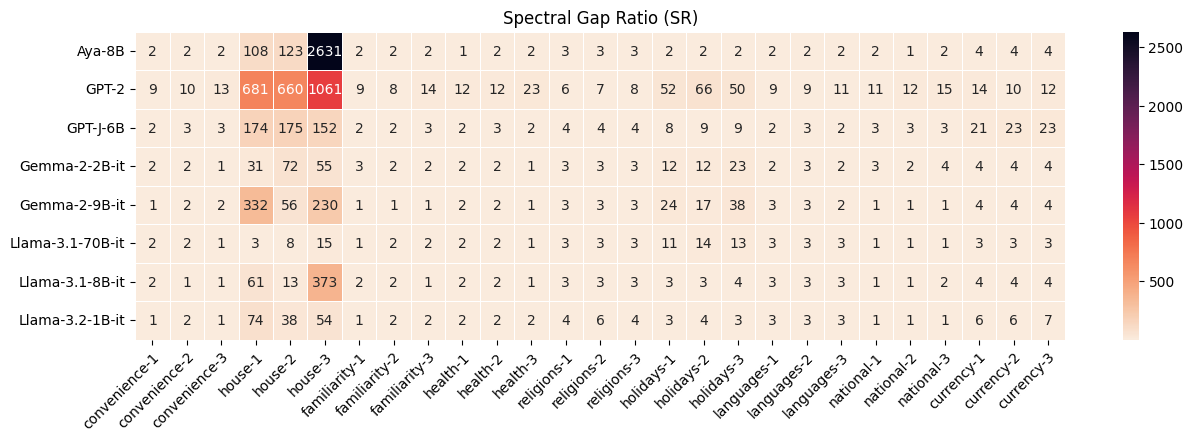

In [10]:
""" ER and SR Heatmaps (Figure 5 and 6)"""
col_order = ['convenience-1', 'convenience-2', 'convenience-3', 'house-1', 'house-2', 'house-3', 
             'familiarity-1', 'familiarity-2', 'familiarity-3', 'health-1', 'health-2', 'health-3', 
             'religions-1', 'religions-2', 'religions-3', 'holidays-1', 'holidays-2', 'holidays-3', 
             'languages-1', 'languages-2', 'languages-3', 'national-1', 'national-2', 'national-3', 
             'currency-1', 'currency-2', 'currency-3']

fig = plt.figure(figsize=(15, 4))
g=sns.heatmap(classification_results_df.pivot(index="model", columns="question", 
                                              values="effective_rank").fillna(0)[col_order], 
              annot=True, cmap="rocket_r", linewidth=.5, fmt=".0f")
g.set(xlabel=None)
g.set(ylabel=None)
plt.setp(g.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
g.set_title(label="Effective Rank (ER)")
plt.show()


fig = plt.figure(figsize=(15, 4))
g=sns.heatmap(classification_results_df.pivot(index="model", columns="question", 
                                              values="spectral_ratio").fillna(0)[col_order], 
              annot=True, cmap="rocket_r", linewidth=.5, fmt=".0f")
g.set(xlabel=None)
g.set(ylabel=None)
plt.setp(g.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
g.set_title(label="Spectral Gap Ratio (SR)")
plt.show()

In [11]:
""" Binarizing results """
def categorize(sr, er, ref_sr, ref_er):
    s = "H" if er > ref_er else "L"
    if sr > ref_sr:
        s += "H"
    else:
        s += "L"
    return s
q_map = {'convenience': 'Convenient foods', 'familiarity': 'Common foods', 'health': 'Healthy foods',
         'house': 'House numbers', 'national': 'National dish', 'languages': 'Languages',
         'religions': 'Religions', 'currency': 'Currency', 'holidays': 'Holidays'}
classification_results_df["domain"] = classification_results_df["question"].apply(lambda x: q_map[x.split("-")[0].strip()])
classification_results_df["domain_cluster"] = classification_results_df["domain"].apply(domain_clusters.get)
classification_results_df["pred_domain"] = classification_results_df.apply(lambda x: categorize(x["spectral_ratio"], x["effective_rank"], classification_results_df.spectral_ratio.median(), classification_results_df.effective_rank.median()), 1)
classification_results_df["act_domain"] = classification_results_df["domain_cluster"].apply(lambda x: x.split("(")[-1].split(")")[0].strip())
classification_results_df.head(2)

,question,model,spectral_ratio,effective_rank,domain,domain_cluster,pred_domain,act_domain
0,convenience-2,GPT-2,10.36,1.93,Convenient foods,Most Common (HH),LH,HH
1,house-2,GPT-2,660.35,1.04,House numbers,Most Common (LH),LH,LH


/workspace/miniconda/envs/deep_learning_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/workspace/miniconda/envs/deep_learning_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/workspace/miniconda/envs/deep_learning_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

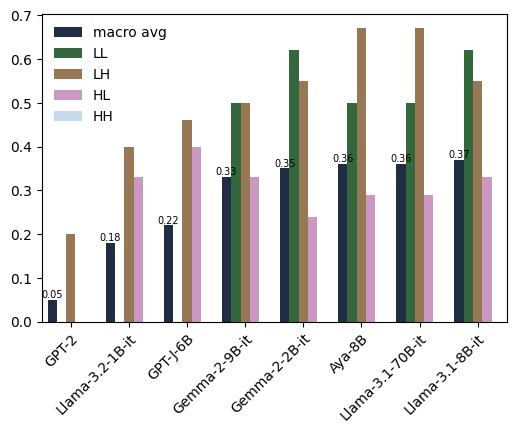

In [12]:
""" Plotting F1 scores (Figure 2)"""
from sklearn.metrics import f1_score, classification_report

grp_df = classification_results_df.groupby(["model"]).agg({"pred_domain": list, "act_domain": list}).reset_index()
grp_df["macro_f1"] = grp_df.apply(lambda x: f1_score(x["act_domain"], x["pred_domain"], average='macro'), 1)
lst = []
for _, row in grp_df.iterrows():
    dct_ = classification_report(row["act_domain"], row["pred_domain"], output_dict=True)
    for k, v in dct_.items():
        if k not in ["accuracy", 'weighted avg']:
            lst.append({**{"model": row["model"], "class": k}, **{p: np.round(q, 2) for p, q in v.items()}})
lst_df = pd.DataFrame(lst)

fig = plt.figure(figsize=(6, 4))
g = sns.barplot(lst_df.sort_values(["class", "f1-score", "model"], ascending=[False, True, True]), x="model", y="f1-score", hue="class", 
                palette=sns.color_palette("cubehelix", 5, as_cmap=False))
g.bar_label(g.containers[0], fontsize=7)
plt.setp(g.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
g.set(xlabel=None)
g.set(ylabel=None)
plt.legend(loc='upper left', title=None, frameon=False)
plt.show()

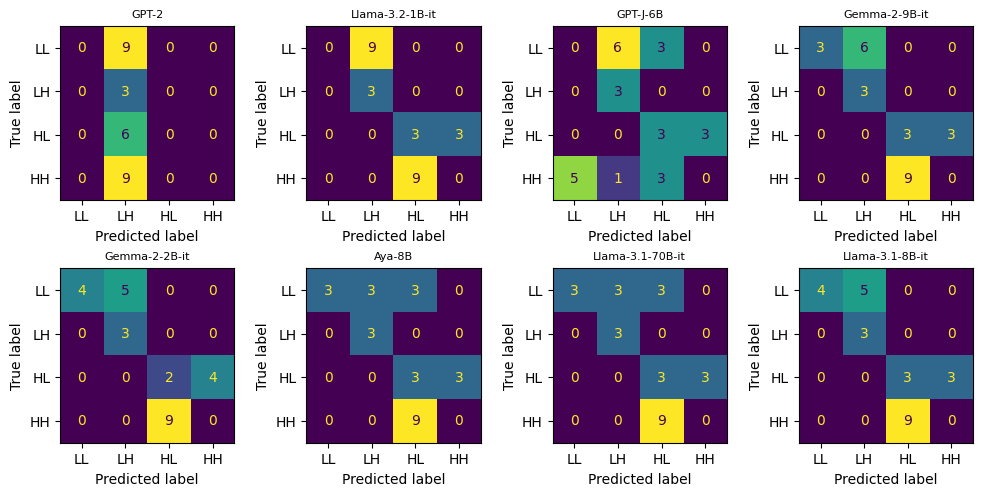

In [13]:
""" Model-wise confusion matrix"""
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

lbl_map = {"LL": 0, "LH": 1, "HL": 2, "HH": 3}
fig, ax = plt.subplots(2, 4, figsize=(10, 5))
mdls = ['GPT-2', 'Llama-3.2-1B-it', 'GPT-J-6B', 'Gemma-2-9B-it', 'Gemma-2-2B-it',
        'Aya-8B', 'Llama-3.1-70B-it', 'Llama-3.1-8B-it']
for ix, m in enumerate(mdls):
    d_ = classification_results_df[(classification_results_df["model"] == m)].reset_index()
    act_, prd_ = [lbl_map[i] for i in d_["act_domain"]], [lbl_map[i] for i in d_["pred_domain"]]
    cm_ = confusion_matrix(act_, prd_)
    dis = ConfusionMatrixDisplay(confusion_matrix=cm_, display_labels=["LL", "LH", "HL", "HH"])
    dis.plot(colorbar=False, ax=ax[ix//4][ix%4])
    ax[ix//4][ix%4].set_title(f"{m}", size=8)

plt.tight_layout()
plt.show()

In [14]:
""" Calculating Bootstrapped CI (95%)"""
def generate_sample_idx(n_boot=10000, random_state=0, n=27):
    rng = np.random.default_rng(random_state)
    return [rng.integers(0, n, n) for _ in range(n_boot)]

def bootstrap_ci2(pred, act, idx_lst, alpha=0.05):
    pred, act = np.asarray(pred), np.asarray(act)
    boot_f1 = []
    for idx in idx_lst:
        boot_f1.append(f1_score(act[idx], pred[idx], average='macro'))
    boot_means = np.array(boot_f1)
    mean_f1 = boot_means.mean()
    macro_f1 = f1_score(act, pred, average='macro')
    low = np.quantile(boot_means, alpha / 2)
    high = np.quantile(boot_means, 1 - alpha / 2)
    return {"mean_f1": mean_f1, "macro_f1": macro_f1, "low": low, "high": high, "boot_f1": boot_means}

bootstrap_list = []
idx_list = generate_sample_idx(n=len(grp_df.iloc[0]["pred_domain"]))
for _, row in tqdm(grp_df.iterrows()):
    res_ = bootstrap_ci2(row["pred_domain"], row["act_domain"], idx_list)
    bootstrap_list.append({**{"model": row["model"]}, **res_})

unlist_df = pd.DataFrame([{"model": i["model"], "f1": j} for i in bootstrap_list for j in i["boot_f1"]])
ordering_map = {'GPT-2': 1, 'Llama-3.1-8B-it': 8, 'GPT-J-6B': 3, 'Aya-8B': 6, 'Gemma-2-9B-it': 4, 
                'Gemma-2-2B-it': 5, 'Llama-3.2-1B-it': 2, 'Llama-3.1-70B-it': 7}
unlist_df["ordering"] = unlist_df["model"].apply(ordering_map.get)
cf_df = pd.DataFrame(bootstrap_list)
cf_df["ordering"] = cf_df["model"].apply(ordering_map.get)
cf_df = cf_df[["model", "macro_f1", "low", "high", "ordering"]].sort_values("ordering").reset_index()
cf_df["macro_f1"] = cf_df["macro_f1"].apply(lambda x: round(x, 3))
cf_df["low"] = cf_df["low"].apply(lambda x: round(x, 3))
cf_df["high"] = cf_df["high"].apply(lambda x: round(x, 3))
cf_df[["model", "macro_f1", "low", "high"]]

8it [00:55,  6.96s/it]


,model,macro_f1,low,high
0,GPT-2,0.050,0.000,0.091
1,Llama-3.2-1B-it,0.183,0.068,0.278
2,GPT-J-6B,0.215,0.083,0.319
3,Gemma-2-9B-it,0.333,0.161,0.483
4,Gemma-2-2B-it,0.349,0.171,0.495
5,Aya-8B,0.363,0.174,0.510
6,Llama-3.1-70B-it,0.363,0.168,0.512
7,Llama-3.1-8B-it,0.374,0.195,0.522


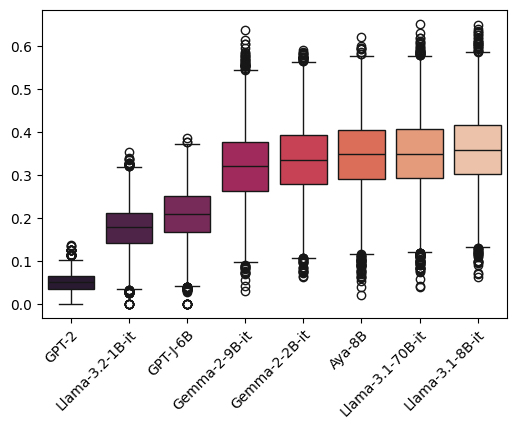

In [15]:
""" Plotting Boxplot """
fig = plt.figure(figsize=(6, 4))
g = sns.boxplot(unlist_df.sort_values("ordering"), x="model", y="f1", hue="model", 
                palette=sns.color_palette("rocket", 8, as_cmap=False))

plt.setp(g.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
g.set(xlabel=None)
g.set(ylabel=None)

plt.show()

In [16]:
""" Pair-wise Model ttest"""
from scipy import stats
from itertools import combinations

bootstrap_dict = {i["model"]: i["boot_f1"] for i in bootstrap_list}
ttest_result = []
model_combos = list(combinations(list(ordering_map.keys()), 2))
for c in list(model_combos):
    t_ = stats.ttest_ind(bootstrap_dict[c[0]], bootstrap_dict[c[1]], equal_var=True)
    ttest_result.append({"model_1": c[0], "model_2": c[1], "pvalue": np.round(t_.pvalue, 4)})
ttest_result_df = pd.DataFrame(ttest_result).pivot(index="model_1", columns="model_2", values="pvalue")
ttest_result_df

model_2,Aya-8B,GPT-J-6B,Gemma-2-2B-it,Gemma-2-9B-it,Llama-3.1-70B-it,Llama-3.1-8B-it,Llama-3.2-1B-it
model_1,,,,,,,
Aya-8B,NaN,NaN,0.0,0.0,0.5663,NaN,0.0
GPT-2,0.0,0.0,0.0,0.0,0.0000,0.0,0.0
GPT-J-6B,0.0,NaN,0.0,0.0,0.0000,NaN,0.0
Gemma-2-2B-it,NaN,NaN,NaN,NaN,0.0000,NaN,0.0
Gemma-2-9B-it,NaN,NaN,0.0,NaN,0.0000,NaN,0.0
Llama-3.1-8B-it,0.0,0.0,0.0,0.0,0.0000,NaN,0.0
Llama-3.2-1B-it,NaN,NaN,NaN,NaN,0.0000,NaN,NaN


In [17]:
""" Spearman correlation between rankings """
from scipy.stats import spearmanr, kendalltau, rankdata

def ranks_from_order(order):
    """order: list of model names in rank order (best first)"""
    return {m: i+1 for i, m in enumerate(order)}

def align_rank_vectors(list1, list2):
    r1 = ranks_from_order(list1)
    r2 = ranks_from_order(list2)
    common = [m for m in r1 if m in r2]  # intersection, in list1 order
    x = np.array([r1[m] for m in common], dtype=float)
    y = np.array([r2[m] for m in common], dtype=float)
    return x, y, common

def corr_with_ci(x, y, B=10000, seed=0):
    """Returns Spearman rho & Kendall tau-b with 95% bootstrap CIs."""
    rng = np.random.default_rng(seed)
    n = len(x)
    # point estimates + p-values
    rho, p_rho = spearmanr(x, y)             # Spearman
    tau, p_tau = kendalltau(x, y)            # Kendall tau-b
    # bootstrap CIs
    rhos = []
    taus = []
    for _ in range(B):
        idx = rng.integers(0, n, n)
        xb, yb = x[idx], y[idx]
        rhos.append(spearmanr(xb, yb).statistic)
        taus.append(kendalltau(xb, yb).statistic)
    rhos = np.array(rhos); taus = np.array(taus)
    ci_rho = (np.quantile(rhos, 0.025), np.quantile(rhos, 0.975))
    ci_tau = (np.quantile(taus, 0.025), np.quantile(taus, 0.975))
    out = {
        "spearman_rho": rho, "spearman_p": p_rho, "spearman_ci95": ci_rho,
        "kendall_tau_b": tau, "kendall_p": p_tau, "kendall_ci95": ci_tau,
        "n_items": n
    }
    return out

list1 = ["Llama-3.1-8B-it", "Llama-3.1-70B-it", "Aya-8B", "Gemma-2-2B-it", "Gemma-2-9B-it", "Llama-3.2-1B-it"]#["M3", "M1", "M2", "M4", "M5"]      # best→worst
list2 = ["Llama-3.1-8B-it", "Llama-3.1-70B-it", "Aya-8B", "Gemma-2-2B-it", "Llama-3.2-1B-it", "Gemma-2-9B-it"]#["M1", "M3", "M2", "M5", "M4"]
list3 = ["Llama-3.1-8B-it", "Llama-3.1-70B-it", "Aya-8B", "Llama-3.2-1B-it", "Gemma-2-2B-it", "Gemma-2-9B-it"]#["M1", "M3", "M2", "M5", "M4"]

print(""" Spearman Between Macrostructure ranking and APR Ranking""")
x, y, common = align_rank_vectors(list1, list2)
res = corr_with_ci(x, y, B=5000)
print("Common items:", common)
for k, v in res.items():
    print(k, ":", v)

print(""" Spearman Between Macrostructure ranking and INT Ranking""")
x, y, common = align_rank_vectors(list1, list3)
res = corr_with_ci(x, y, B=5000)
print("Common items:", common)
for k, v in res.items():
    print(k, ":", v)    

 Spearman Between Macrostructure ranking and APR Ranking
Common items: ['Llama-3.1-8B-it', 'Llama-3.1-70B-it', 'Aya-8B', 'Gemma-2-2B-it', 'Gemma-2-9B-it', 'Llama-3.2-1B-it']
spearman_rho : 0.942857142857143
spearman_p : 0.004804664723032055
spearman_ci95 : (0.5151515151515151, 1.0)
kendall_tau_b : 0.8666666666666666
kendall_p : 0.016666666666666666
kendall_ci95 : (0.3846153846153847, 1.0)
n_items : 6
 Spearman Between Macrostructure ranking and INT Ranking
Common items: ['Llama-3.1-8B-it', 'Llama-3.1-70B-it', 'Aya-8B', 'Gemma-2-2B-it', 'Gemma-2-9B-it', 'Llama-3.2-1B-it']
spearman_rho : 0.8285714285714287
spearman_p : 0.04156268221574334
spearman_ci95 : (0.03145161290322608, 1.0)
kendall_tau_b : 0.7333333333333333
kendall_p : 0.05555555555555555
kendall_ci95 : (0.0, 1.0)
n_items : 6
